In [8]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import StandardScaler

from os.path import join

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir
add_to_path(join(root_dir, 'src'))
import anomaly_detection.deep_learning.AE_GRU as AE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Already in sys: c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\Projet-recheche-INSA-anomaly-detection-librairy\src


D'après l'étude faite dans anl01p2-data_exploration.ipynb on ne garde uniquement les 29 suivantes sessions.

In [9]:

# On charge directement les données propres
df_filtered = pd.read_parquet('dataset_propre.parquet', engine='fastparquet')

print(f"Données chargées ! Dimensions : {df_filtered.shape}")
print(f"Nombre de sessions saines : {df_filtered['session_id'].nunique()}")
df_filtered.head()


Données chargées ! Dimensions : (277191, 18)
Nombre de sessions saines : 29


,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-05-03 19:05:09.479,1907.07,2018.21,1996.95,1970.14,4422.54,4075.89,6260.59,7115.34,4.78839,3.52983,0.636276,0.009091,-0.521420,247.341,7.44903,0.00,T24S12-04_E-AL2780
1,2024-05-03 19:05:09.489,1907.07,2013.49,2002.41,1975.34,2897.10,3615.71,7652.36,8646.26,4.87162,2.78240,0.215994,-0.121585,-0.883973,247.430,8.36016,0.01,T24S12-04_E-AL2780
2,2024-05-03 19:05:09.499,1912.77,2018.21,2000.23,1971.18,3840.65,3477.77,8482.17,10067.30,4.55949,2.94489,0.401888,-0.062186,-0.453441,247.430,7.10343,0.02,T24S12-04_E-AL2780
3,2024-05-03 19:05:09.509,1908.02,2020.57,2003.51,1972.22,4740.16,4735.44,7680.30,8673.72,4.67394,3.19403,0.345311,0.009091,-0.748015,247.518,9.58547,0.03,T24S12-04_E-AL2780
4,2024-05-03 19:05:09.519,1910.87,2018.21,2004.60,1979.50,2863.49,3576.30,7678.65,8378.51,4.95486,2.56576,0.312982,-0.133464,-0.951951,247.607,11.21920,0.04,T24S12-04_E-AL2780


Séparation en un jeu d'entrainement et un jeu de test 

In [10]:

# Liste des noms des sessions 
all_sessions = df_filtered['session_id'].unique()

# Sélection aléatoire de 6 sessions (environ 20% de 29)
random.seed(40)
test_sessions = random.sample(list(all_sessions), 6)
train_sessions = [s for s in all_sessions if s not in test_sessions]

print(f"Sessions d'entraînement : {train_sessions}")
print(f"Sessions de test : {test_sessions}")

df_train = df_filtered[df_filtered['session_id'].isin(train_sessions)].copy()
df_test = df_filtered[df_filtered['session_id'].isin(test_sessions)].copy()


Sessions d'entraînement : ['T24S12-04_E-AL2780', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3143', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3319', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438', 'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3690']
Sessions de test : ['T24S12-04_E-AL3280', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL2870', 'T24S12-04_E-AL3033', 'T24S12-04_E-AL3070']


In [11]:

#on sélectionne uniquement les colonnes que l'on va utiliser
features = [c for c in df_filtered.columns if c not in ['session_id', 'time_real', 'datetime']]

#normalisation avec la moyenne et la variance des données d'entraînement
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

In [12]:

def create_sequences(df_input, features_list, time_steps):
    sequences_list = []
    for _, df_session in df_input.groupby('session_id'):
        values = df_session[features_list].values
        if len(values) >= time_steps:
            seq=[]
            for i in range(len(values) - time_steps + 1):
                seq.append(values[i : (i + time_steps),:])
            sequences_list.append(np.array(seq))
    return np.vstack(sequences_list)



In [13]:
# CRÉATION DES FENÊTRES PAR SESSION (Pour éviter les chevauchements)
TIME_STEPS = 100 

# On fusionne tout en un seul gros bloc 3D
x_train = create_sequences(df_train, features, TIME_STEPS)
x_test = create_sequences(df_test, features, TIME_STEPS)

print(f"Shape x_train : {x_train.shape}")
print(f"Shape x_test : {x_test.shape}")

Shape x_train : (217863, 100, 15)
Shape x_test : (56457, 100, 15)


Le paramètre TIME_STEPS a été fixé à 100 (soit 1 secondes pour 100 Hz) afin de fournir au modèle une fenêtre temporelle correspondant à la durée typique d'un événement dynamique du véhicule (freinage, braquage), lui permettant de comprendre le contexte physique sans saturer sa mémoire à court terme. => Source ?

In [14]:
model = AE.build_autoencoder(time_steps=x_train.shape[1], nb_features=x_train.shape[2])

# On affiche le résumé de l'architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 64)        │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 100, 32)        │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 100, 64)        │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 15)        │           975 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,087 (199.56 KB)

 Trainable params: 51,087 (199.56 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Sécurité : Si l'erreur (loss) ne descend plus pendant 3 tours (patience=3), on arrête !
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Début entrainement")

# 2. Lancement de l'apprentissage
history = model.fit(
    x=x_train, 
    y=x_train,            # X et Y sont les mêmes !
    epochs=30,            # Nombre maximum de passages sur toutes tes données
    batch_size=256,       # On lui donne les fenêtres par paquets de 256 (soulage la RAM)
    validation_split=0.1, # On garde 10% des données de côté pour évaluer l'IA à chaque tour
    callbacks=[early_stop]
)

print("✅ Entraînement terminé !")

Début entrainement
Epoch 1/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 616s 623ms/step - loss: 0.1146 - val_loss: 0.0872
Epoch 2/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 567s 588ms/step - loss: 0.0749 - val_loss: 0.0833
Epoch 3/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 562s 582ms/step - loss: 0.0723 - val_loss: 0.0806
Epoch 4/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 585s 606ms/step - loss: 0.0704 - val_loss: 0.0791
Epoch 5/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 580s 601ms/step - loss: 0.0687 - val_loss: 0.0782
Epoch 6/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 559s 579ms/step - loss: 0.0676 - val_loss: 0.0794
Epoch 7/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 573s 594ms/step - loss: 0.0660 - val_loss: 0.0786
Epoch 8/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 593s 614ms/step - loss: 0.0649 - val_loss: 0.0755
Epoch 9/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 733s 759ms/step - loss: 0.0644 - val_loss: 0.0756
Epoch 10/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 701s 727ms/step - loss: 0.0637 - val_loss: 0.0751
Epoch 11/30
965/965 ━━━━━━━━━━━━━━━━━━━━ 586s 607ms/step - loss: 0.0630 - val_lo

KeyboardInterrupt: 

🔍 Calcul des prédictions sur les données saines (ça peut prendre 1 ou 2 minutes)...
8573/8573 ━━━━━━━━━━━━━━━━━━━━ 251s 29ms/step


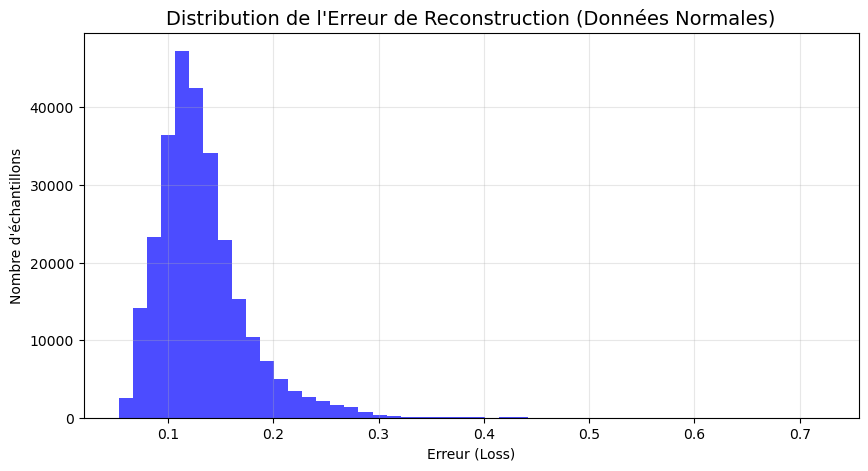

🚨 Seuil d'anomalie défini à : 0.7224


In [ ]:

print("🔍 Calcul des prédictions sur les données saines (ça peut prendre 1 ou 2 minutes)...")
# 1. On demande au modèle de reconstruire les données normales
x_train_pred = model.predict(x_train)

# 2. On calcule l'Erreur Absolue Moyenne (MAE) ou MSE entre l'original et la reconstruction
# On fait la moyenne sur les 100 pas de temps et les 15 capteurs pour chaque fenêtre
train_mae_loss = np.mean(np.abs(x_train_pred - x_train), axis=(1, 2))

# 3. On trace l'histogramme de l'erreur pour visualiser
plt.figure(figsize=(10, 5))
plt.hist(train_mae_loss, bins=50, color='blue', alpha=0.7)
plt.title("Distribution de l'Erreur de Reconstruction (Données Normales)", fontsize=14)
plt.xlabel("Erreur (Loss)")
plt.ylabel("Nombre d'échantillons")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Définition du seuil (Threshold)
# Règle classique : Le seuil est le maximum de l'erreur sur les données normales,
# ou la moyenne + 3 fois l'écart-type (pour être plus robuste).
seuil = np.max(train_mae_loss)
print(f"🚨 Seuil d'anomalie défini à : {seuil:.4f}")